# Notebook to perform Cluster evaluation and analysis of CosMX RNA Data

# TODO
- 

## Instructions

- 

## Imports

In [26]:
# Load Packages
library(Seurat)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(gridExtra)
library(patchwork)
library(data.table)
library(Matrix)
library(harmony)
library(ggrepel)
library(pals)
library(RColorBrewer)
library(ggrastr)
library(cluster)
library(ggrepel)
library(gtools)
library(tibble)
library(scPearsonPCA)
library(fs)
library(InSituCor)
library(pheatmap)
library(grid)
library(ComplexHeatmap)
library(viridis)
library(circlize)
library(AUCell)
library(tictoc)
library(readxl)
library(HieraType)
# library(reshape2)

In [27]:
# Load helper functions
source("helper_functions.R")

## Data Loading

In [28]:
# Define directories
seu_file_path <- file.path("../outputs/TMA18/seurat_objects/merged_object_TMA18_IST_louvain_initial.RDS")
out_dir <- "../outputs" # Folder for outputs
study_name <- "TMA18"
out_dir_seu <- file.path(out_dir, study_name, "seurat_objects")
full_out_dir <- file.path(out_dir, study_name, "ClusterEval")
dir.create(full_out_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir_seu, showWarnings = FALSE, recursive = TRUE)

Define Parameters

In [29]:
ASSAY_NAME <- "RNA"
reduction <- "scpearson_umap_nobatch"
sdimx_col <- "x_slide_mm"
sdimy_col <- "y_slide_mm"
study_id_col <- "study_id"
region_col <- "region"
annotation_col <- "scpearson_clusters_nobatch_res1.2"
# annotation_col <- "broad_annotation"

# Subset
subset <- FALSE

Loading Seurat object

In [30]:
# Load Seurat object
seu <- readRDS(seu_file_path)

In [31]:
colnames(seu@meta.data)
head(seu@meta.data, n=5)

[1] "fov"                                                                                                          
  [2] "Area"                                                                                                         
  [3] "AspectRatio"                                                                                                  
  [4] "x_FOV_px"                                                                                                     
  [5] "y_FOV_px"                                                                                                     
  [6] "Width"                                                                                                        
  [7] "Height"                                                                                                       
  [8] "Mean.PanCK"                                                                                                   
  [9] "Max.PanCK"                                                                                                    
 [10] "Mean.G"                                                                                                       
 [11] "Max.G"                                                                                                        
 [12] "Mean.Membrane"                                                                                                
 [13] "Max.Membrane"                                                                                                 
 [14] "Mean.CD45"                                                                                                    
 [15] "Max.CD45"                                                                                                     
 [16] "Mean.DAPI"                                                                                                    
 [17] "Max.DAPI"                                                                                                     
 [18] "SplitRatioToLocal"                                                                                            
 [19] "NucArea"                                                                                                      
 [20] "NucAspectRatio"                                                                                               
 [21] "Circularity"                                                                                                  
 [22] "Eccentricity"                                                                                                 
 [23] "Perimeter"                                                                                                    
 [24] "Solidity"                                                                                                     
 [25] "cell_id"                                                                                                      
 [26] "assay_type"                                                                                                   
 [27] "version"                                                                                                      
 [28] "Run_Tissue_name"                                                                                              
 [29] "Panel"                                                                                                        
 [30] "cellSegmentationSetId"                                                                                        
 [31] "cellSegmentationSetName"                                                                                      
 [32] "slide_ID_numeric"                                                                                             
 [33] "x_slide_mm"                                                                                                   
 [34] "y_slide_mm"                                                                                          

,fov,Area,AspectRatio,x_FOV_px,y_FOV_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.G,⋯,GABAergic.synapse,Gap.Junctions,Glutamatergic.synapse,Microglia.Neurodegenerative.Phenotype..MGnD.,Myelogenesis,Neuroactive.Ligands.and.Receptors,Neurogenesis,Oligodendrocyte.Differentiation,Transmitter.Response,Transmitter.Storage
,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
18_c_1_100_100,100,23200,0.79,1848,915,207,164,1099.8,3272,371.9,⋯,0.006132972,0.051336898,0.01585921,0.04934135,0.04145120,0.03343709,0.1521876,0.0344877345,0.04864658,0.03100233
18_c_1_100_107,100,2805,0.92,1713,926,57,62,1391.7,3480,366.9,⋯,0.021275441,0.000000000,0.03598344,0.05497601,0.00155955,0.03868360,0.1880175,0.0000962001,0.04341164,0.00000000
18_c_1_100_113,100,9714,0.87,2185,1009,133,153,1034.4,2408,332.1,⋯,0.033378562,0.009014515,0.02770186,0.00000000,0.03426906,0.03424039,0.1780356,0.0406926407,0.02076949,0.02975913
18_c_1_100_123,100,6857,0.73,584,1043,83,113,871.4,1332,340.7,⋯,0.024477612,0.006722689,0.02989648,0.00000000,0.01305097,0.02701074,0.1608036,0.0253968254,0.03051583,0.03830614
18_c_1_100_157,100,8809,0.99,2257,1291,109,110,782.8,4068,274.9,⋯,0.033487110,0.000000000,0.04028986,0.03913805,0.02721005,0.02020785,0.2076031,0.0348725349,0.03098400,0.03830614


Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


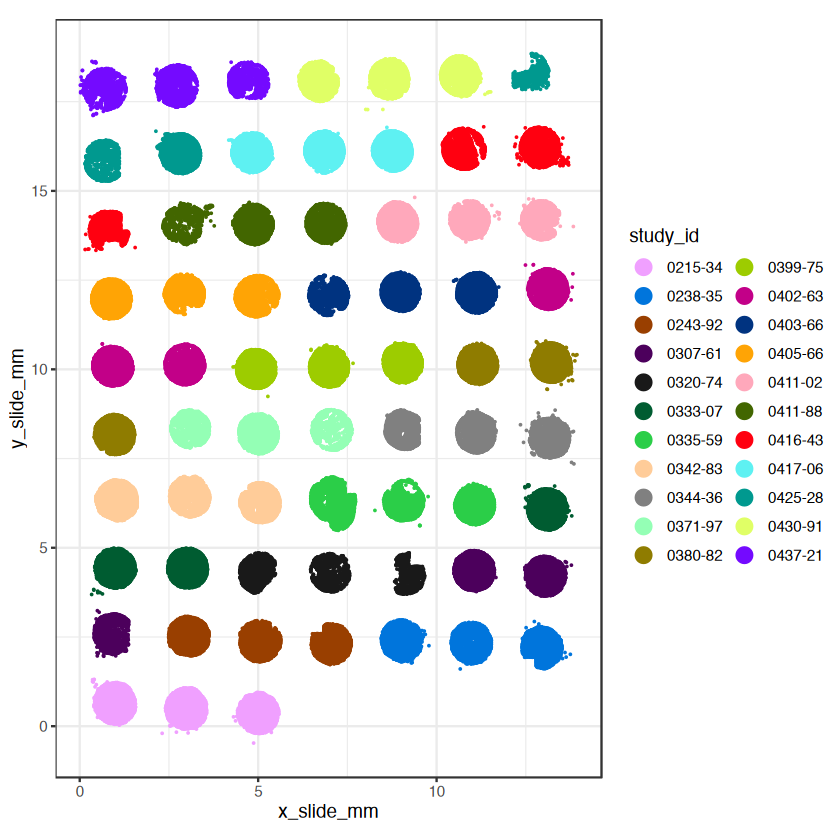

In [32]:
# Visualize the data
xyplot(study_id_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [33]:
unique(seu@meta.data[[study_id_col]])
unique(seu@meta.data[[region_col]])

[1] "0411-88" "0405-66" "0402-63" "0425-28" "0371-97" "0342-83" "0333-07"
 [8] "0243-92" "0215-34" "0437-21" "0416-43" "0417-06" "0399-75" "0320-74"
[15] "0430-91" "0403-66" "0335-59" "0411-02" "0344-36" "0238-35" "0380-82"
[22] "0307-61"

[1] 13 14 15 2  16 17 18 19 20 21 3  22 23 24 25 26 1  27 28 29 30 31 32 4  33
[26] 34 35 36 37 38 39 40 41 42 5  43 44 45 46 47 48 49 50 51 52 6  53 54 55 56
[51] 57 58 59 60 61 62 63 7  64 65 66 8  9  10 11 12
66 Levels: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 66

Setting

In [53]:
# Total count normalization — uses same logic/names as the standalone snippet
counts <- Matrix::t(seu[[ASSAY_NAME]]$counts)
metadata <- seu@meta.data
scale_row <- mean(metadata$nCount_RNA) / metadata$nCount_RNA
norm <- counts
norm@x <- norm@x * scale_row[norm@i + 1L]

# Store back into Seurat data layer (transpose back to genes x cells)
seu <- SetAssayData(seu, assay = "RNA", layer = "data", new.data = Matrix::t(norm))

message(sprintf("Normalized %d cells x %d genes (mean library size: %.1f)",
                nrow(norm), ncol(norm), mean(metadata$nCount_RNA)))

Normalized 206450 cells x 6175 genes (mean library size: 1419.4)



## Subclustering Analysis

Self-contained section for subsetting to a single cluster and re-running the full pipeline (HVGs, PCA, UMAP, graph, clusters) on the subsetted cells. This captures biological variation specific to the subpopulation that may be invisible in the global PCA.

To re-run for a different cluster, change `subcluster_annotation_col` and `subcluster_target` in the configuration cell below and re-execute all cells in this section.

In [54]:
# === Subclustering Configuration ===
subcluster_annotation_col <- annotation_col  # Column to filter on (e.g. "scpearson_clusters_nobatch_res1.2", "broad_annotation")
subcluster_target <- "0"                     # Cluster/label to subset
subcluster_resolution <- 0.8                 # Louvain resolution for subclustering
subcluster_nfeatures <- 3000                 # Number of HVGs
subcluster_nperclust <- 15                   # Top markers per subcluster
subcluster_prefix <- paste0("subclust_", subcluster_target)  # Prefix for reduction/cluster slot names (encodes parent)

# Output directory for subclustering results
subclust_out_dir <- file.path(full_out_dir, "Subclustering", paste0(subcluster_annotation_col, "_", subcluster_target))
dir.create(subclust_out_dir, showWarnings = FALSE, recursive = TRUE)

In [55]:
# Subset to target cluster
seu_sub <- subset(seu, cells = colnames(seu)[seu@meta.data[[subcluster_annotation_col]] == subcluster_target])
seu_sub@meta.data <- droplevels(seu_sub@meta.data)
message(sprintf("Subsetted to %d cells from cluster '%s'", ncol(seu_sub), subcluster_target))

Subsetted to 28705 cells from cluster '0'



In [56]:
# Re-run full pipeline on subset: HVGs -> PCA -> UMAP -> Graph -> Clusters
slot_names_sub <- list(
    pca      = paste0(subcluster_prefix, "_pca"),
    umap     = paste0(subcluster_prefix, "_umap"),
    graph    = paste0(subcluster_prefix, "_graph"),
    clusters = paste0(subcluster_prefix, "_clusters")
)

results_sub <- suppressMessages(suppressWarnings(
    apply_scPearsonPCA(seu_sub,
                       nfeatures = subcluster_nfeatures,
                       slot_names = slot_names_sub,
                       resolution = subcluster_resolution)
))

seu_sub <- results_sub$seu
subclust_col <- paste0(slot_names_sub$clusters, "_res", subcluster_resolution)
message(sprintf("Found %d subclusters at resolution %s",
                length(unique(seu_sub@meta.data[[subclust_col]])), subcluster_resolution))

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 28705
Number of edges: 575166

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.5504
Number of communities: 9
Elapsed time: 3 seconds


Found 9 subclusters at resolution 0.8



In [58]:
slot_names_sub$umap
paste0(slot_names_sub$clusters, "_res", subcluster_resolution)

[1] "subclust_0_umap"

[1] "subclust_0_clusters_res0.8"

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


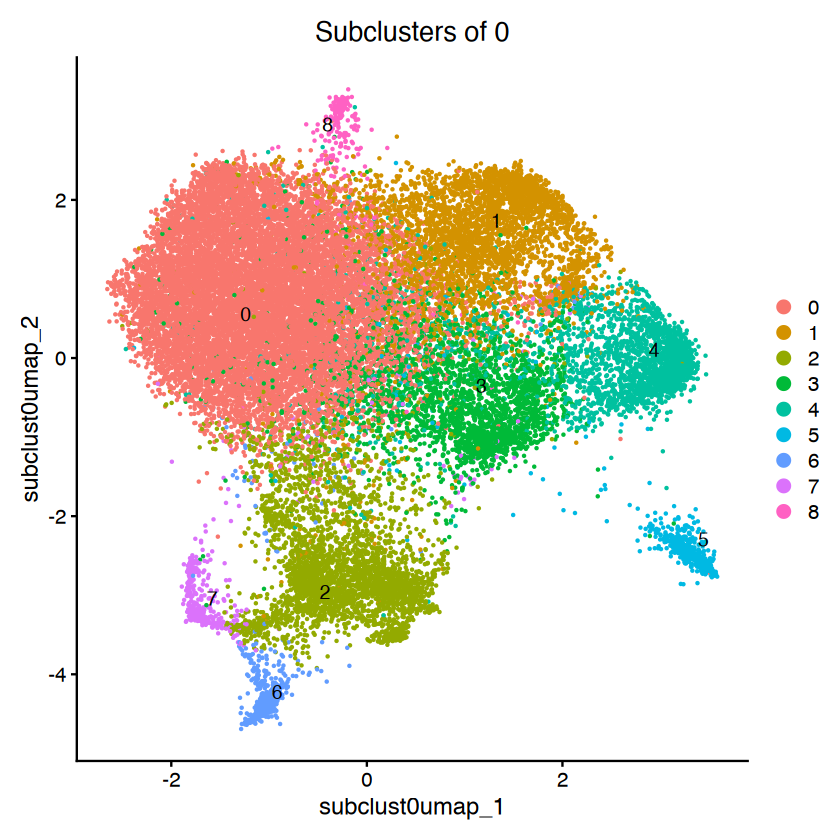

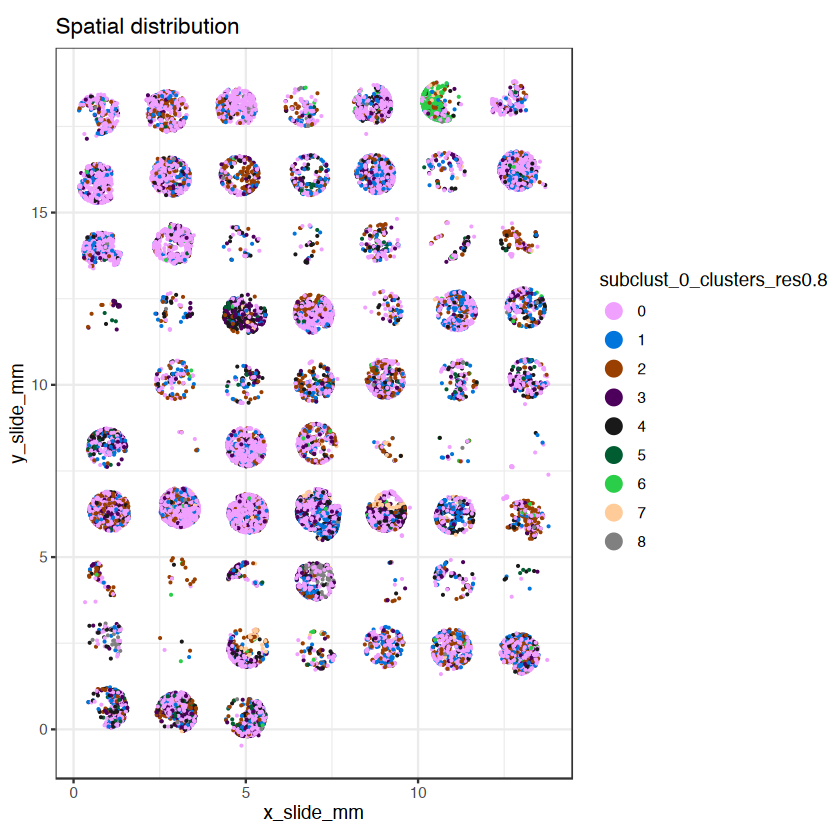

In [59]:
# UMAP of subclusters
p1 <- DimPlot(seu_sub, reduction = slot_names_sub$umap, group.by = subclust_col,
              label = TRUE, repel = TRUE) + ggtitle(paste0("Subclusters of ", subcluster_target))

# Spatial plot of subclusters
p2 <- xyplot(subclust_col, metadata = seu_sub@meta.data, ptsize = 0.1) +
      coord_fixed() + ggtitle("Spatial distribution")

print(p1)
print(p2)

In [60]:
# Compute marker genes per subcluster
counts_sub <- Matrix::t(seu_sub[["RNA"]]$counts)
metadata_sub <- seu_sub@meta.data
cell_id_col_sub <- "cell_ID_new"

markers_sub <- HieraType::clusterwise_foldchange_metrics(
    Matrix::t(counts_sub),
    metadata = metadata_sub,
    cluster_column = subclust_col,
    cellid_column = cell_id_col_sub
)

# Prioritize markers: fold change penalizing low expressers
markers_sub$prioritystat <- (markers_sub$cluster_expr + 0.025) / (markers_sub$clusterprime_expr + 0.025)

markersshort_sub <- c()
for (name in unique(markers_sub$cluster)) {
    inds <- markers_sub$cluster == name
    top <- order(markers_sub$prioritystat[inds], decreasing = TRUE)
    top <- top[seq_len(min(subcluster_nperclust, sum(inds)))]
    markersshort_sub <- c(markersshort_sub, markers_sub$gene[inds][top])
}
markersshort_sub <- unique(markersshort_sub)

message(sprintf("Top markers: %d genes across %d subclusters",
                length(markersshort_sub), length(unique(markers_sub$cluster))))

  |======================================================================| 100%

Top markers: 124 genes across 9 subclusters



In [61]:
# Build filtered marker table: top N markers per subcluster by prioritystat (all columns)
marker_table_sub <- do.call(rbind, lapply(split(markers_sub, markers_sub$cluster), function(df) {
    df <- df[df$cluster_prop >= 0.05, ]
    df <- df[order(df$prioritystat, decreasing = TRUE), ]
    head(df, subcluster_nperclust)
}))
marker_table_sub <- as.data.frame(marker_table_sub)
rownames(marker_table_sub) <- NULL

# Round numeric columns for readability
num_cols <- c("cluster_expr", "clusterprime_expr", "fold_change", "cluster_prop", "fold_change_prop", "prioritystat")
num_cols <- intersect(num_cols, colnames(marker_table_sub))
marker_table_sub[, num_cols] <- round(marker_table_sub[, num_cols], 2)

# Save as CSV
marker_table_filepath <- file.path(subclust_out_dir,
    paste0("Subcluster_MarkerTable_", subcluster_annotation_col, "_", subcluster_target, ".csv"))
write.csv(marker_table_sub, marker_table_filepath, row.names = FALSE)

message(sprintf("Saved marker table (%d rows, %d subclusters) to: %s",
                nrow(marker_table_sub), length(unique(marker_table_sub$cluster)), marker_table_filepath))

Saved marker table (135 rows, 9 subclusters) to: ../outputs/TMA18/ClusterEval/Subclustering/scpearson_clusters_nobatch_res1.2_0/Subcluster_MarkerTable_scpearson_clusters_nobatch_res1.2_0.csv



In [62]:
# Marker heatmap
hm_sub <- HieraType::marker_heatmap(markers_sub)

hm_filepath <- file.path(subclust_out_dir, paste0("Subcluster_Markers_Heatmap_", subcluster_annotation_col, "_", subcluster_target, ".pdf"))
pdf(hm_filepath, width = 20, height = 10)
print(hm_sub)
dev.off()

message(sprintf("Saved marker heatmap to: %s", hm_filepath))

agg_record_1743397065 
                    2

Saved marker heatmap to: ../outputs/TMA18/ClusterEval/Subclustering/scpearson_clusters_nobatch_res1.2_0/Subcluster_Markers_Heatmap_scpearson_clusters_nobatch_res1.2_0.pdf



In [63]:
# Save subcluster Seurat object and markers
seu_sub_filepath <- file.path(out_dir_seu,
    paste0("subcluster_", subcluster_annotation_col, "_", subcluster_target, "_", study_name, "_res", subcluster_resolution, ".RDS"))
saveRDS(seu_sub, seu_sub_filepath)

markers_sub_filepath <- file.path(subclust_out_dir,
    paste0("Subcluster_Markers_", subcluster_annotation_col, "_", subcluster_target, ".RDS"))
saveRDS(markers_sub, markers_sub_filepath)

message(sprintf("Saved Seurat object to: %s", seu_sub_filepath))
message(sprintf("Saved markers to: %s", markers_sub_filepath))

Saved Seurat object to: ../outputs/TMA18/seurat_objects/subcluster_scpearson_clusters_nobatch_res1.2_0_TMA18_res0.8.RDS

Saved markers to: ../outputs/TMA18/ClusterEval/Subclustering/scpearson_clusters_nobatch_res1.2_0/Subcluster_Markers_scpearson_clusters_nobatch_res1.2_0.RDS



# Deep Dive

In [72]:
# --- Genes of Interest (GOI) analysis ---
goi <- c("GDNF", "NPY2R")

# Get normalized expression matrix for GOIs
expr_mat <- GetAssayData(
  seu_sub,
  assay = "RNA",
  layer = "data"
)[goi, , drop = FALSE]

# Logical matrix of expression > 0
pos_mat <- expr_mat > 0

# Cells positive for ALL genes
keep_cells <- colnames(expr_mat)[colSums(pos_mat) == length(goi)]
seu_goi <- subset(seu_sub, cells = keep_cells)

# Summary stats
n_express <- length(keep_cells)
n_total   <- ncol(seu_sub)
frac      <- n_express / n_total

mean_all <- rowMeans(expr_mat)
mean_pos <- rowMeans(expr_mat[, keep_cells, drop = FALSE])

message(sprintf("GOIs: %s", paste(goi, collapse = ", ")))
message(sprintf("Cells expressing all genes: %d / %d (%.2f%%)", 
                n_express, n_total, frac * 100))

for (g in goi) {
  message(sprintf(
    "%s | Mean (all cells): %.4f | Mean (co-expressing cells): %.4f",
    g,
    mean_all[g],
    mean_pos[g]
  ))
}


GOIs: GDNF, NPY2R

Cells expressing all genes: 180 / 28705 (0.63%)

GDNF | Mean (all cells): 0.3456 | Mean (co-expressing cells): 4.3830

NPY2R | Mean (all cells): 0.4217 | Mean (co-expressing cells): 4.3118



In [73]:
# Get normalized expression matrix for GOI+ cells
expr_mat <- GetAssayData(seu_goi, assay = "RNA", layer = "data")

# Compute per-gene summary statistics across GOI+ cells
gene_stats <- data.frame(
    gene         = rownames(expr_mat),
    mean_expr    = rowMeans(expr_mat),
    pct_express  = rowSums(expr_mat > 0) / ncol(expr_mat) * 100,
    stringsAsFactors = FALSE
) %>%
    arrange(desc(mean_expr)) %>%
    mutate(rank = row_number())

head(gene_stats, 30)

,gene,mean_expr,pct_express,rank
,<chr>,<dbl>,<dbl>,<int>
COL1A1,COL1A1,5.517674,45.00000,1
COX2,COX2,5.312419,54.44444,2
MHC I,MHC I,4.837169,61.11111,3
DUSP2,DUSP2,4.820583,64.44444,4
GDNF,GDNF,4.382988,100.00000,5
NPY2R,NPY2R,4.311827,100.00000,6
COX1,COX1,3.145687,45.00000,7
NDUFA3,NDUFA3,2.631183,45.55556,8
A1BG,A1BG,2.360210,40.55556,9


In [ ]:
# top_n <- 30

# gene_stats %>%
#     slice_head(n = top_n) %>%
#     mutate(gene = factor(gene, levels = rev(gene))) %>%
#     ggplot(aes(x = mean_expr, y = gene)) +
#     geom_col(fill = "steelblue") +
#     labs(title = paste0("Top ", top_n, " genes by mean expression in ", goi, "+ cells (n=", n_express, ")"),
#          x = "Mean normalized expression", y = NULL) +
#     theme_minimal()

In [ ]:
# # Add GOI status to metadata and run Wilcoxon DE
# seu_sub$goi_status <- ifelse(colnames(seu_sub) %in% goi_cells, "GOI_pos", "GOI_neg")
# Idents(seu_sub) <- "goi_status"

# de_results <- FindMarkers(seu_sub, ident.1 = "GOI_pos", ident.2 = "GOI_neg",
#                           test.use = "wilcox", logfc.threshold = 0.1, min.pct = 0.05)
# de_results <- de_results %>%
#     rownames_to_column("gene") %>%
#     arrange(p_val_adj, desc(abs(avg_log2FC)))

# head(de_results, 30)

In [ ]:
# de_results %>%
#     mutate(sig = p_val_adj < 0.05 & abs(avg_log2FC) > 0.25) %>%
#     ggplot(aes(x = avg_log2FC, y = -log10(p_val_adj), color = sig)) +
#     geom_point_rast(size = 0.8, alpha = 0.6) +
#     geom_text_repel(data = . %>% filter(sig) %>% slice_head(n = 15),
#                     aes(label = gene), size = 3, max.overlaps = 15) +
#     scale_color_manual(values = c("grey70", "firebrick")) +
#     labs(title = paste0("DE: ", goi, "+ vs ", goi, "- cells"),
#          x = "avg log2 FC", y = "-log10(adj p-value)") +
#     theme_minimal() + theme(legend.position = "none")

In [ ]:
FeaturePlot(seu_sub, features = goi, reduction = slot_names_sub$umap, order = TRUE) +
    scale_colour_viridis(option = "magma") +
    ggtitle(paste0(goi, " expression"))